
# Plane Crashes Data Profiling (2 - cleaned dataset)

**Objective:** Profile and summarize the cleaned dataset to assess data quality, completeness, and analytic readiness.


## LIBRARY


In [79]:
import os
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


## DIRECTORY PATH & DATABASE CONNECTION

In [80]:
# Project directory
project_dir = os.path.join(os.path.expanduser("~"), "OneDrive", "Project_Code", "JobProject-MCCSS")


In [81]:
# Create SQLAlchemy engine
db_path = os.path.join(project_dir, "data", "raw", "plane_crashes_data.db")
engine = create_engine(f'sqlite:///{db_path}')

df = pd.read_sql_table("plane_crashes_clean", engine)

# Close the connection
engine.dispose()

In [82]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   crash_id                         5783 non-null   int64  
 1   date_month_num                   5783 non-null   int64  
 2   date_year_num                    5783 non-null   int64  
 3   date_crash                       5783 non-null   object 
 4   time_is_approximate              5783 non-null   int64  
 5   time_is_utc                      5783 non-null   int64  
 6   time_crash                       3675 non-null   object 
 7   time_of_day_type                 3675 non-null   object 
 8   time_is_AM                       5783 non-null   int64  
 9   crash_location_is_approximate    5783 non-null   int64  
 10  crash_location_environment_type  5783 non-null   object 
 11  crash_location_text              5777 non-null   object 
 12  operator_text       

In [83]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 5783, Columns: 37


<code style="color:orange">Notes</code>:

- Total rows: 5,783
- 37 columns:
    - some columns have missing values
    - columns have now being formated

Let's check a few rows.

In [84]:
df.sample(10)

,crash_id,date_month_num,date_year_num,date_crash,time_is_approximate,time_is_utc,time_crash,time_of_day_type,time_is_AM,crash_location_is_approximate,...,serial_fuselage_nbr_text,aboard_total_count,aboard_passengers_count,aboard_crew_count,fatalities_total_count,fatalities_passengers_count,fatalities_crew_count,ground_fatalities_count,summary_full_text,summary_short_text
210,211,12,1929,1929-12-02,0,0,None,None,0,0,...,622,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The mail plane crashed en route during a storm.,The mail plane crashed en route during a storm
4031,4032,1,1989,1989-01-29,0,0,None,None,0,0,...,4124,11.0,7.0,4.0,11.0,7.0,4.0,0.0,Crashed about 500 ft. short of the runway.,Crashed about 500 ft
4386,4387,4,1993,1993-04-02,0,0,None,None,0,0,...,4700/83,11.0,8.0,3.0,11.0,8.0,3.0,0.0,Crashed into the sea after departing Caracas o...,Crashed into the sea after departing Caracas o...
5128,5129,2,2003,2003-02-10,0,0,19:42,Evening,0,0,...,1AJ006-04,3.0,0.0,3.0,2.0,0.0,2.0,0.0,"Shortly after takeoff, the aircraft stalled, c...","Shortly after takeoff, the aircraft stalled, c..."
3190,3191,8,1977,1977-08-01,0,0,12:36,Afternoon,0,0,...,None,2.0,1.0,1.0,2.0,1.0,1.0,0.0,"The helicopter, piloted by Francis Gary Powers...","The helicopter, piloted by Francis Gary Powers..."
2938,2939,8,1974,1974-08-05,0,0,None,None,0,0,...,11850,11.0,8.0,3.0,5.0,2.0,3.0,0.0,Struck high ground while attempting to land at...,Struck high ground while attempting to land at St
564,565,6,1940,1940-06-14,0,0,14:00,Afternoon,0,0,...,5494,9.0,7.0,2.0,9.0,7.0,2.0,0.0,The plane was en route when it was shot down b...,The plane was en route when it was shot down b...
1235,1236,9,1951,1951-09-12,1,0,12:30,Afternoon,0,0,...,15985/32733,39.0,36.0,3.0,39.0,36.0,3.0,0.0,Crashed into the Mediterranean due to structur...,Crashed into the Mediterranean due to structur...
3584,3585,9,1982,1982-09-04,0,0,None,None,0,0,...,25B-119,10.0,8.0,2.0,10.0,8.0,2.0,0.0,The plane ran out of fuel on the third approac...,The plane ran out of fuel on the third approac...
1445,1446,10,1954,1954-10-24,0,0,17:50,Evening,0,1,...,20510,21.0,18.0,3.0,21.0,18.0,3.0,0.0,"Crashed in the Alps, 25 miles northeast of Nic...","Crashed in the Alps, 25 miles northeast of Nic..."


## Missing Values Analysis

In [85]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

df_missing = pd.DataFrame({'missing_count': missing_counts, 
                           'missing_percent': missing_percent}).sort_values('missing_percent', ascending=False)

df_missing

,missing_count,missing_percent
registration_part2_text,5667,97.994121
flight_no_text,4501,77.831575
time_of_day_type,2108,36.451669
time_crash,2108,36.451669
route_text,1495,25.851634
route_to_multiple_text,1495,25.851634
route_sep_count,1495,25.851634
route_from_text,1495,25.851634
serial_fuselage_nbr_text,1207,20.871520
fatalities_passengers_count,558,9.648971


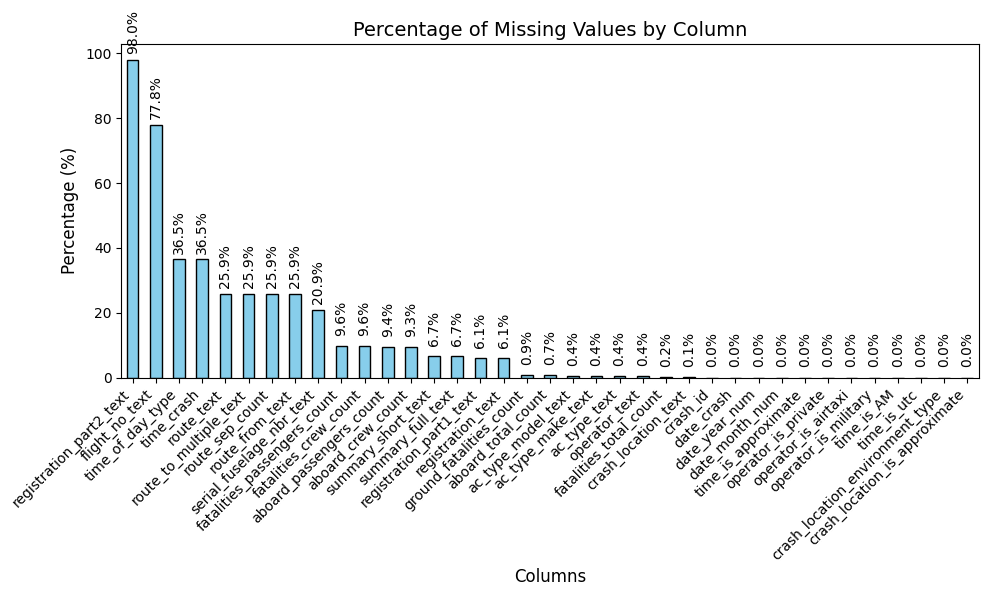

In [86]:
ax = df_missing['missing_percent'].plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')

ax.set_title('Percentage of Missing Values by Column', fontsize=14)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Columns', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 20), 
                textcoords='offset points',
                rotation=90)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<code style="color:orange">Notes</code>:

- **Registration** column:
    - 98% of missing in registration_part2
    - registration_part1 has only 6.1% os missing
    - Registration column was split into two parts using a delimiter `/`.

- **Flight No** colum:
    - 77.8% of the db is missing, likely to be removed from the db

- **Time** column: 
    - 36% of the db doe not have time and this will aftect the columns that we derive from it:
        - time_is_approximate
        - time_is_utc
        - time_of_day_type
        - time_is_AM
    
- **Route** column:
    - 25.9% of missing values and all the derived columns shows the same amount.
        - route_sep_count
        - rout_from_text
        - route_to_multiple_text

- **Aboard** & **Fatalities** columns:
    - Crew & Passengers derived columns have ~9.5% os missing each
    - Total have 0.7% & 0.2% respectively
    - Verify but probably (Crew + Passengers) **will not equal to** Total

- **Registration** & **Summary** columns:
    - ~6.5% each not so bad

- **Date** and flag columns created don't have any missing values:
    - Good for `date_crash`
    - Question: if `crash_time` is NULL should the time_is_utc also be NULL? Now out default is 0. (valid for all other flags)

## Duplicates Observations

### Entire rows duplicated

In [87]:
# Identify entirely duplicated rows (all columns identical)
entire_duplicates = df[df.duplicated(keep=False)]

print(f"Number of entirely duplicated records: {entire_duplicates.shape[0]}")
if not entire_duplicates.empty:
    display(entire_duplicates)
else:
    print("No entirely duplicated rows found.")

Number of entirely duplicated records: 0
No entirely duplicated rows found.


<code style="color:orange">Notes</code>:

Confirming what we saw in SQL, entire row duplicated are difficult to find as most of the variables are free-text.

### Unique Obvious Combination: Date / Time / Location

In [88]:
# Check for duplicate rows using date, time, and location as a composite key
dup_mask = df.duplicated(subset=['date_crash', 'time_crash', 'crash_location_text'], keep=False)
duplicates = df[dup_mask]

print(f"Number of duplicated records (by date, time, location): {duplicates.shape[0]}")
if not duplicates.empty:
    display(duplicates.sort_values(by=['date_crash', 'time_crash', 'crash_location_text']))
else:
    print("No duplicates found based on date, time, and location.")

Number of duplicated records (by date, time, location): 4


,crash_id,date_month_num,date_year_num,date_crash,time_is_approximate,time_is_utc,time_crash,time_of_day_type,time_is_AM,crash_location_is_approximate,...,serial_fuselage_nbr_text,aboard_total_count,aboard_passengers_count,aboard_crew_count,fatalities_total_count,fatalities_passengers_count,fatalities_crew_count,ground_fatalities_count,summary_full_text,summary_short_text
673,674,11,1943,1943-11-19,0,0,None,None,0,0,...,None,3.0,0.0,3.0,3.0,0.0,3.0,0.0,A navigational error caused the cargo plane to...,A navigational error caused the cargo plane to...
674,675,11,1943,1943-11-19,0,0,None,None,0,0,...,None,3.0,0.0,3.0,2.0,0.0,2.0,0.0,The cargo plane crashed short of the runway in...,The cargo plane crashed short of the runway in...
4993,4994,3,2001,2001-03-29,0,0,19:01,Evening,0,1,...,303,18.0,15.0,3.0,18.0,15.0,3.0,0.0,The small jet crashed on final approach to Run...,The small jet crashed on final approach to Run...
4994,4995,3,2001,2001-03-29,0,0,19:01,Evening,0,1,...,303,18.0,15.0,3.0,18.0,15.0,3.0,0.0,The aircraft was on final approach to Sardy Fi...,The aircraft was on final approach to Sardy Fi...


<code style="color:orange">Notes</code>:

- 4 rows were detected as duplicated
    - crash_id: 674 & 675: summary, fatalities total count (-1), aircraft type and registration are different but everything else seems the same
    - crash_id: 4994 & 4995: summary, route (one has city and state, the other just city) and aircraft type are different.

- RESOLVE: keep first occurence


### Unique Obvious Combination: Date / Location / Registration

In [89]:
# Check for duplicate rows using date, registration, and location as a composite key
dup_mask = df.duplicated(subset=['date_crash', 'crash_location_text', 'registration_text'], keep=False)
duplicates = df[dup_mask]

print(f"Number of duplicated records (by date, location, registration): {duplicates.shape[0]}")
if not duplicates.empty:
    display(duplicates.sort_values(by=['date_crash', 'crash_location_text', 'registration_text']))
else:
    print("No duplicates found based on date, location and registration.")

Number of duplicated records (by date, location, registration): 4


,crash_id,date_month_num,date_year_num,date_crash,time_is_approximate,time_is_utc,time_crash,time_of_day_type,time_is_AM,crash_location_is_approximate,...,serial_fuselage_nbr_text,aboard_total_count,aboard_passengers_count,aboard_crew_count,fatalities_total_count,fatalities_passengers_count,fatalities_crew_count,ground_fatalities_count,summary_full_text,summary_short_text
2370,2371,2,1968,1968-02-29,0,0,22:43,Night,0,1,...,187010601,84.0,75.0,9.0,83.0,74.0,9.0,0.0,After an emergency situation and emergency des...,After an emergency situation and emergency des...
2371,2372,2,1968,1968-02-29,0,0,None,None,0,1,...,187010601,82.0,73.0,9.0,82.0,73.0,9.0,0.0,None,None
4993,4994,3,2001,2001-03-29,0,0,19:01,Evening,0,1,...,303,18.0,15.0,3.0,18.0,15.0,3.0,0.0,The small jet crashed on final approach to Run...,The small jet crashed on final approach to Run...
4994,4995,3,2001,2001-03-29,0,0,19:01,Evening,0,1,...,303,18.0,15.0,3.0,18.0,15.0,3.0,0.0,The aircraft was on final approach to Sardy Fi...,The aircraft was on final approach to Sardy Fi...


<code style="color:orange">Notes</code>:

- 4 rows were detected as duplicated
    - crash_id: 2371 & 2372: time, summary, fatalities total count, aboard total count  are different but everything else seems the same
    - crash_id: 4994 & 4995: summary, route (one has city and state, the other just city) and aircraft type are different (already spotted)

- RESOLVE: keep first occurence

### Unique Obvious Combination: Date / Location / Aircraft Type

In [90]:
# Check for duplicate rows using date, aircraft type, and location as a composite key
dup_mask = df.duplicated(subset=['date_crash', 'crash_location_text', 'ac_type_text'], keep=False)
duplicates = df[dup_mask]

print(f"Number of duplicated records (by date, location, aircraft type): {duplicates.shape[0]}")
if not duplicates.empty:
    display(duplicates.sort_values(by=['date_crash', 'crash_location_text', 'ac_type_text']))
else:
    print("No duplicates found based on date, location and aircraft type.")

Number of duplicated records (by date, location, aircraft type): 4


,crash_id,date_month_num,date_year_num,date_crash,time_is_approximate,time_is_utc,time_crash,time_of_day_type,time_is_AM,crash_location_is_approximate,...,serial_fuselage_nbr_text,aboard_total_count,aboard_passengers_count,aboard_crew_count,fatalities_total_count,fatalities_passengers_count,fatalities_crew_count,ground_fatalities_count,summary_full_text,summary_short_text
2318,2319,7,1967,1967-07-25,0,0,None,None,0,1,...,None,18.0,15.0,3.0,18.0,15.0,3.0,0.0,Crashed en route.,Crashed en route
2319,2320,7,1967,1967-07-25,1,0,10:30,Morning,1,1,...,None,16.0,13.0,3.0,16.0,13.0,3.0,0.0,Struck a mountain in the Phou Pha Bon range wh...,Struck a mountain in the Phou Pha Bon range wh...
2370,2371,2,1968,1968-02-29,0,0,22:43,Night,0,1,...,187010601,84.0,75.0,9.0,83.0,74.0,9.0,0.0,After an emergency situation and emergency des...,After an emergency situation and emergency des...
2371,2372,2,1968,1968-02-29,0,0,None,None,0,1,...,187010601,82.0,73.0,9.0,82.0,73.0,9.0,0.0,None,None


<code style="color:orange">Notes</code>:

- 4 rows were detected as duplicated
    - crash_id: 2319 & 2320: time, summary, operator, route, registration,  aboard total count, fatality total count
    - crash_id: 2371 & 2372: time, summary, fatalities total count, aboard total count  are different but everything else seems the same (already spotted)

- RESOLVE: keep 2320 and 2371 more complete

### Unique Obvious Combination: Date / Location

In [91]:
# Check for duplicate rows using date and location as a composite key
dup_mask = df.duplicated(subset=['date_crash', 'crash_location_text'], keep=False)
duplicates = df[dup_mask]

print(f"Number of duplicated records (by date, location): {duplicates.shape[0]}")
if not duplicates.empty:
    display(duplicates.sort_values(by=['date_crash', 'crash_location_text']))
else:
    print("No duplicates found based on date and location.")

Number of duplicated records (by date, location): 12


,crash_id,date_month_num,date_year_num,date_crash,time_is_approximate,time_is_utc,time_crash,time_of_day_type,time_is_AM,crash_location_is_approximate,...,serial_fuselage_nbr_text,aboard_total_count,aboard_passengers_count,aboard_crew_count,fatalities_total_count,fatalities_passengers_count,fatalities_crew_count,ground_fatalities_count,summary_full_text,summary_short_text
673,674,11,1943,1943-11-19,0,0,None,None,0,0,...,None,3.0,0.0,3.0,3.0,0.0,3.0,0.0,A navigational error caused the cargo plane to...,A navigational error caused the cargo plane to...
674,675,11,1943,1943-11-19,0,0,None,None,0,0,...,None,3.0,0.0,3.0,2.0,0.0,2.0,0.0,The cargo plane crashed short of the runway in...,The cargo plane crashed short of the runway in...
2196,2197,2,1966,1966-02-17,0,0,01:38,Night,1,0,...,64M472,66.0,47.0,19.0,21.0,8.0,13.0,0.0,"While taking off, the aircraft struck a snow d...","While taking off, the aircraft struck a snow d..."
2197,2198,2,1966,1966-02-17,0,0,None,None,0,0,...,None,21.0,NaN,NaN,21.0,NaN,NaN,NaN,Crashed on takeoff.,Crashed on takeoff
2318,2319,7,1967,1967-07-25,0,0,None,None,0,1,...,None,18.0,15.0,3.0,18.0,15.0,3.0,0.0,Crashed en route.,Crashed en route
2319,2320,7,1967,1967-07-25,1,0,10:30,Morning,1,1,...,None,16.0,13.0,3.0,16.0,13.0,3.0,0.0,Struck a mountain in the Phou Pha Bon range wh...,Struck a mountain in the Phou Pha Bon range wh...
2370,2371,2,1968,1968-02-29,0,0,22:43,Night,0,1,...,187010601,84.0,75.0,9.0,83.0,74.0,9.0,0.0,After an emergency situation and emergency des...,After an emergency situation and emergency des...
2371,2372,2,1968,1968-02-29,0,0,None,None,0,1,...,187010601,82.0,73.0,9.0,82.0,73.0,9.0,0.0,None,None
4993,4994,3,2001,2001-03-29,0,0,19:01,Evening,0,1,...,303,18.0,15.0,3.0,18.0,15.0,3.0,0.0,The small jet crashed on final approach to Run...,The small jet crashed on final approach to Run...
4994,4995,3,2001,2001-03-29,0,0,19:01,Evening,0,1,...,303,18.0,15.0,3.0,18.0,15.0,3.0,0.0,The aircraft was on final approach to Sardy Fi...,The aircraft was on final approach to Sardy Fi...


<code style="color:orange">Notes</code>:

- 12 rows were detected as duplicated
    - crash_id:  674 &  675: already spotted
    - crash_id: 2197 & 2198: first observation is more complete.
    - crash_id: 2319 & 2320: already spotted
    - crash_id: 2371 & 2372: already spotted
    - crash_id: 4994 & 4995: already spotted
    - crash_id: 5017 & 5018: summary is helpful to identify this one as not being duplicated, as they are part of the 2001-Sep-11 plane crashed in the Wolrd Trade Center. the time is different, operator and aircraft type.


<code style="color:orange">FINAL NOTE</code>:

|  crash_id   | Date/Time/Location | Date/Location/Registration | Date/Location/Aircraft Type | Date/Location |    Keep     |
| :---------: | :----------------: | :------------------------: | :-------------------------: | :-----------: | :---------: |
| 674 &  675  |         ✔️        |                            |                             |      ✔️       |  674 (1st)  |
| 2197 & 2198 |                    |                            |                             |      ✔️       | 2197  (1st) |
| 2319 & 2320 |                    |                            |             ✔️              |      ✔️       | 2320 (2nd)  |
| 2371 & 2372 |                    |             ✔️             |             ✔️              |      ✔️       | 2371  (1st) |
| 4994 & 4995 |         ✔️        |             ✔️             |                             |      ✔️       | 4994  (1st) |
| 5017 & 5018 |                    |                            |                             |      ✔️       |    both     |



In general, to identify duplicates we want to follow the steps:

1. Full Row Match: All columns identical (drop all but the first occurrence).
2. Critical Composite Keys: Drop duplicates based on the most identifying columns, e.g.:
    - date, time, location
    - date, location, registration
    - date, location, aircraft_type
    - date, location
3. Manual review or domain-specific rules are needed (e.g., if two records differ in registration but represent the same event due to data entry errors).


In order to automate the rules, for each group of potential duplicates:
- If duplicates are found at a stricter level (e.g., all columns or date/time/location), keep the first occurrence (or the one with most non-null values or complete information).
- If duplicates only match at a looser level (e.g., only date/location), consider keeping both unless additional evidence suggests they’re the same event.
- When in doubt, retain both records but flag them for review.

### Deduplicate Rule Approach

Based on discovery above, we will follow the strict rule and keep first record.
We know that when doing that we will loose `2320` wich was the best information and we will not remove `2198`.

Rationale:
- This approach prioritizes automation and reproducibility over manual review, which is impractical at scale.

Limitations:
- Some records with potentially more complete or accurate information (e.g., crash_id 2320) may be dropped in favor of the first occurrence.
- Some near-duplicates (e.g., crash_id 2198) that do not match strictly on the chosen keys may be retained.

Trade-off:
Accept a small risk of retaining less informative records or missing merged details in favor of consistent, scalable deduplication.

Manual Review:
- Manual curation is not feasible for large datasets and will not be performed.


In [92]:
# Remove exact duplicates
df = df.drop_duplicates()

# Remove duplicates by strict composite keys, keeping the first
strict_keys = [
    ['date_crash', 'time_crash', 'crash_location_text'],
    ['date_crash', 'crash_location_text', 'registration_text'],
    ['date_crash', 'crash_location_text', 'ac_type_text'],
    # ['date_crash', 'crash_location_text']
]
for keys in strict_keys:
    df = df.drop_duplicates(subset=keys, keep='first')

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5779 entries, 0 to 5782
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   crash_id                         5779 non-null   int64  
 1   date_month_num                   5779 non-null   int64  
 2   date_year_num                    5779 non-null   int64  
 3   date_crash                       5779 non-null   object 
 4   time_is_approximate              5779 non-null   int64  
 5   time_is_utc                      5779 non-null   int64  
 6   time_crash                       3673 non-null   object 
 7   time_of_day_type                 3673 non-null   object 
 8   time_is_AM                       5779 non-null   int64  
 9   crash_location_is_approximate    5779 non-null   int64  
 10  crash_location_environment_type  5779 non-null   object 
 11  crash_location_text              5773 non-null   object 
 12  operator_text            

In [94]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 5779, Columns: 37


## Field-by-Field Profiling

### Numeric Fields

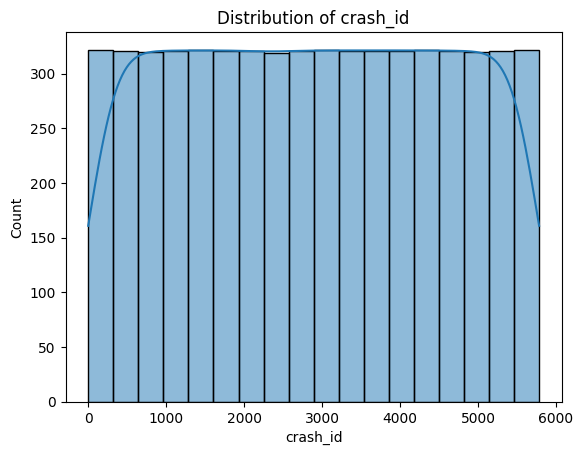

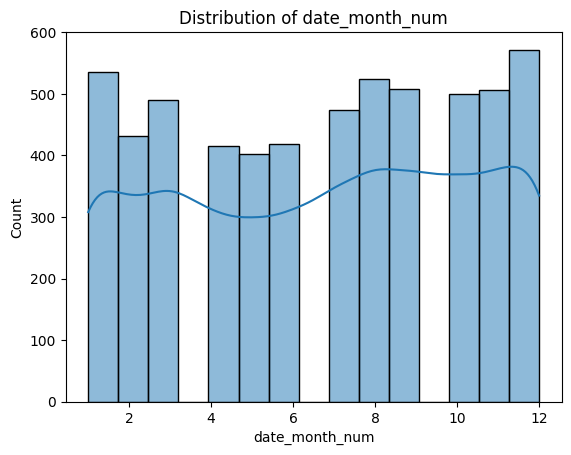

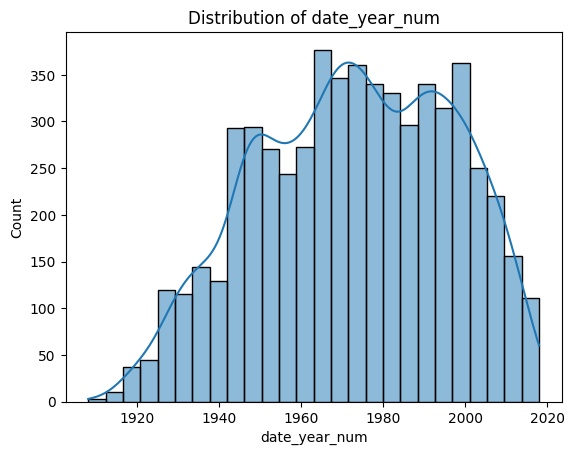

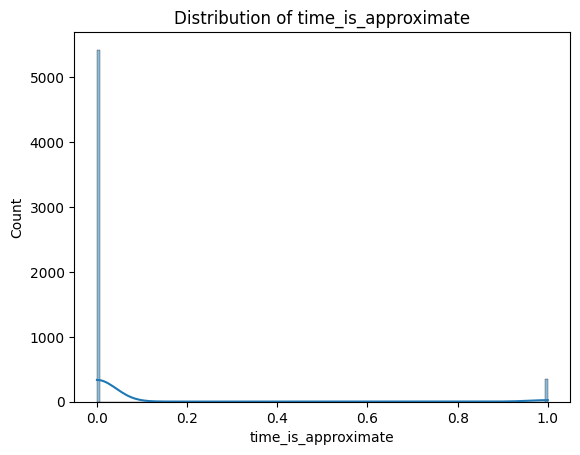

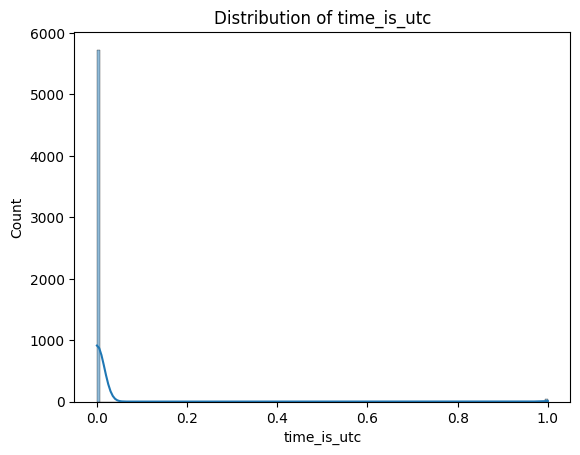

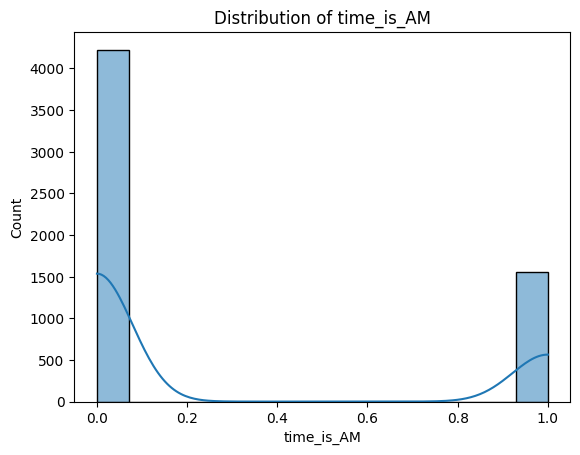

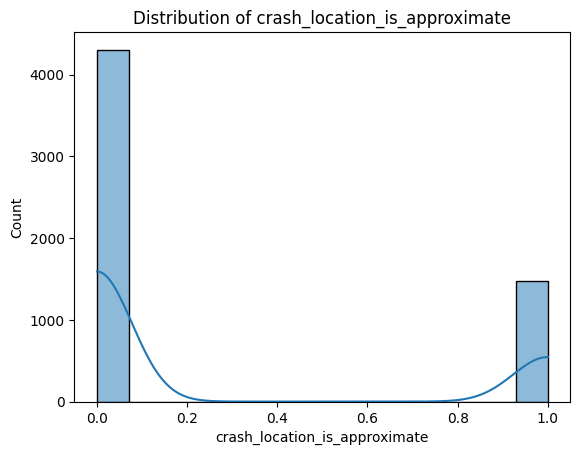

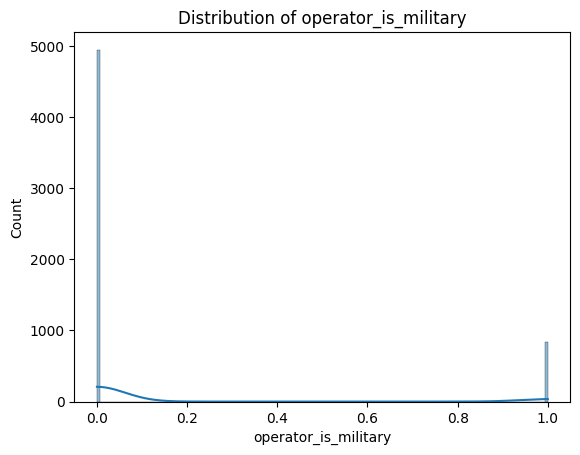

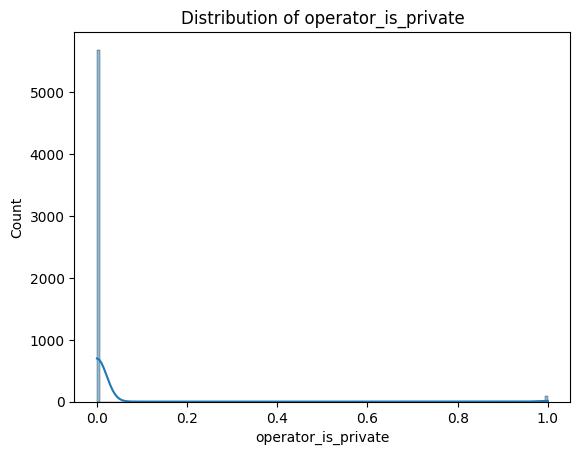

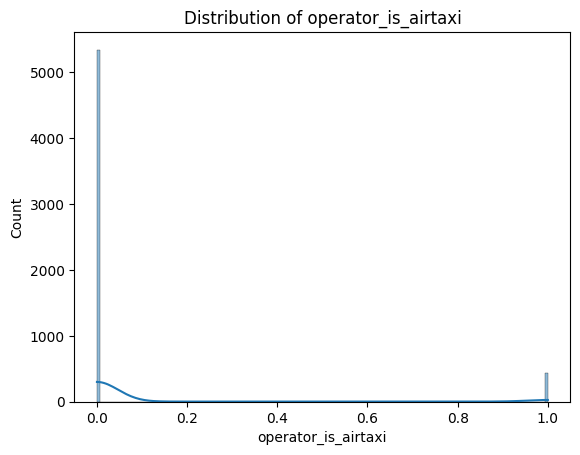

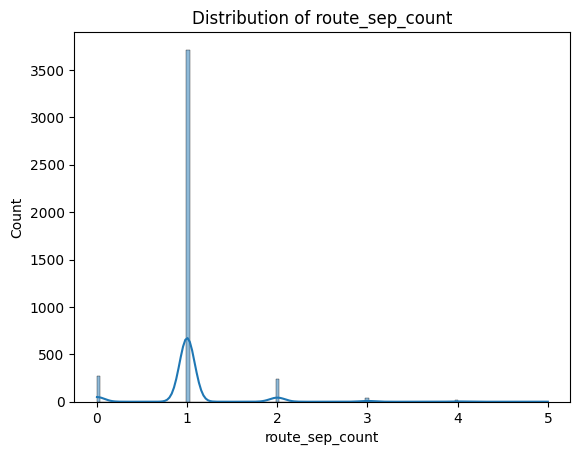

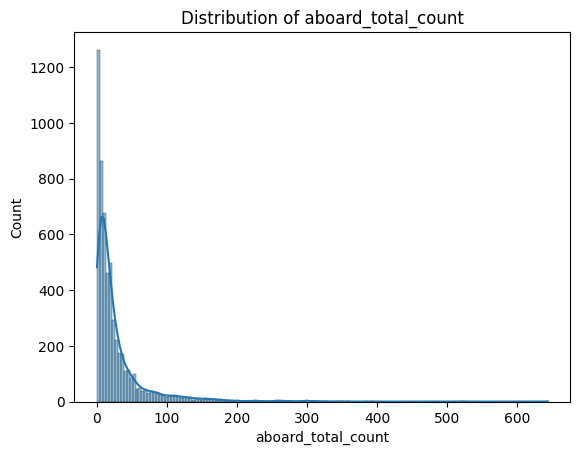

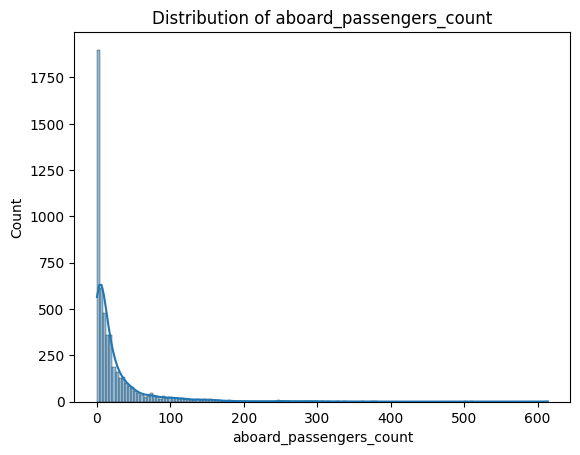

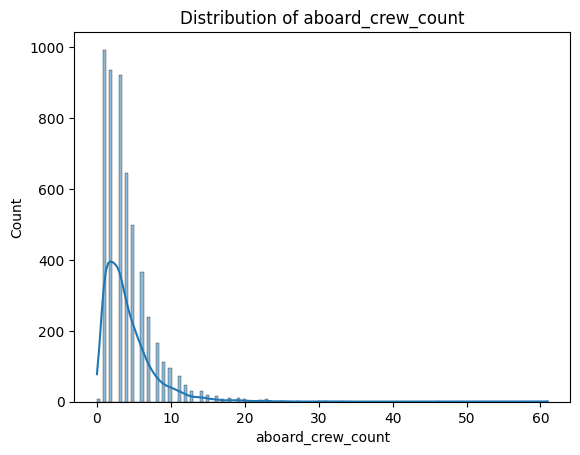

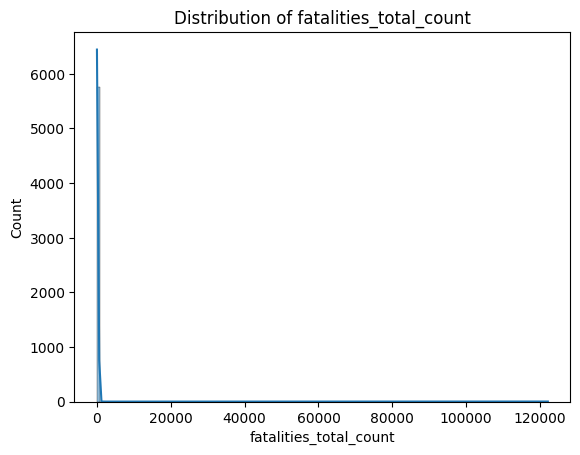

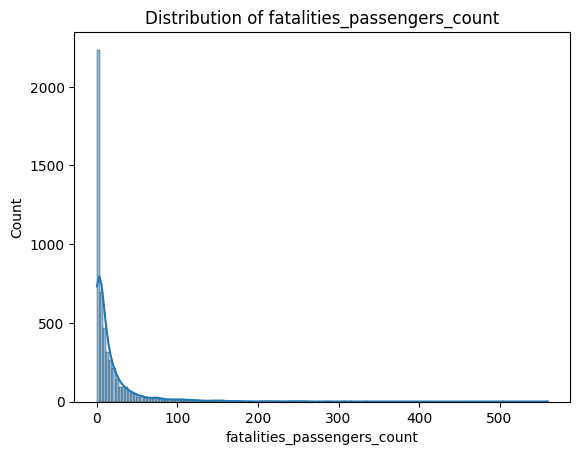

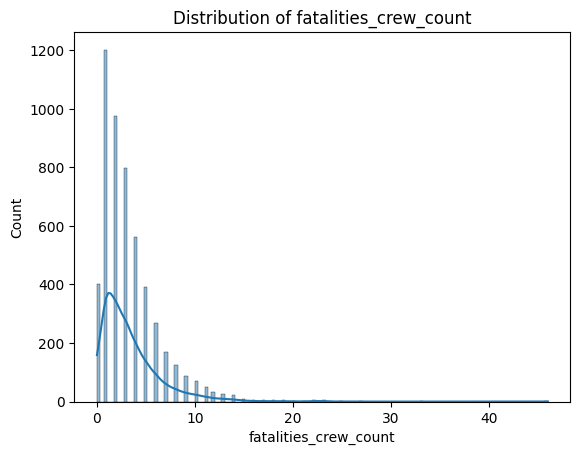

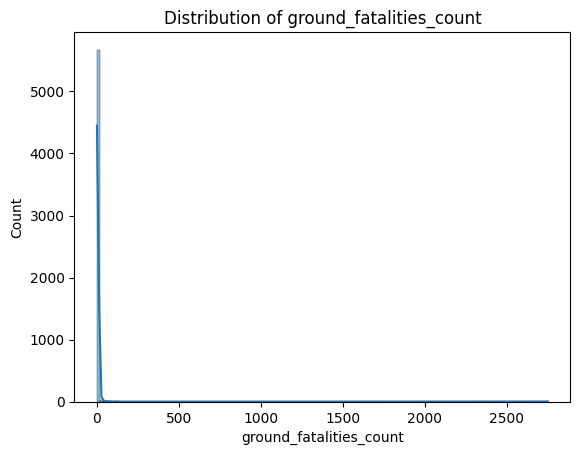

In [95]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].describe().T

for col in num_cols:
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

### Categorical Fields

In [96]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"{col}:")
    print(df[col].value_counts(dropna=False).head(10))
    print('\n')

date_crash:
date_crash
1973-02-28    4
1976-08-28    4
1988-08-31    4
1992-08-27    4
2001-09-11    4
1962-03-08    3
1947-05-29    3
1970-12-31    3
1944-11-29    3
1947-01-25    3
Name: count, dtype: int64


time_crash:
time_crash
None     2106
15:00      38
16:00      37
11:00      37
12:00      36
17:00      36
14:00      35
08:00      32
19:30      30
19:00      29
Name: count, dtype: int64


time_of_day_type:
time_of_day_type
None         2106
Morning      1163
Afternoon    1008
Night         754
Evening       748
Name: count, dtype: int64


crash_location_environment_type:
crash_location_environment_type
Land     5340
Water     439
Name: count, dtype: int64


crash_location_text:
crash_location_text
Moscow, Russia            18
Sao Paulo, Brazil         15
Rio de Janeiro, Brazil    14
New York, New York        14
Manila, Philippines       14
Anchorage, Alaska         13
Cairo, Egypt              13
Bogota, Colombia          13
Chicago, Illinois         11
Atlantic Ocean        

## Date and Time Profiling

1908-09-17 00:00:00 2018-11-06 00:00:00


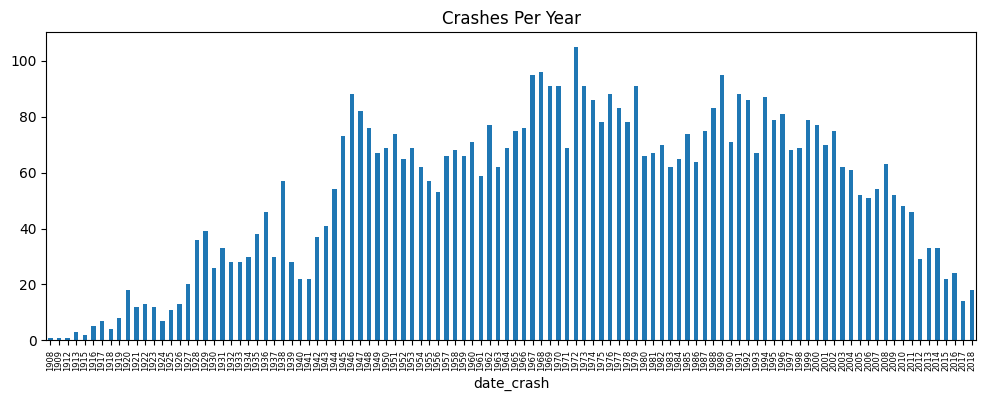

In [97]:
if 'date_crash' in df.columns:
    df['date_crash'] = pd.to_datetime(df['date_crash'], errors='coerce')
    print(df['date_crash'].min(), df['date_crash'].max())
    df['date_crash'].dt.year.value_counts().sort_index().plot(kind='bar', figsize=(12,4))
    plt.title('Crashes Per Year')
    plt.xticks(fontsize=6) 
    plt.show()

<code style="color:orange">Notes</code>:

- Seems that the accidents have been decreasing after their peak ~1970.
- Data observed since 1908-Sep-17 until 2018-Nov-06

## Correlation and Outlier Detection (Numerical)

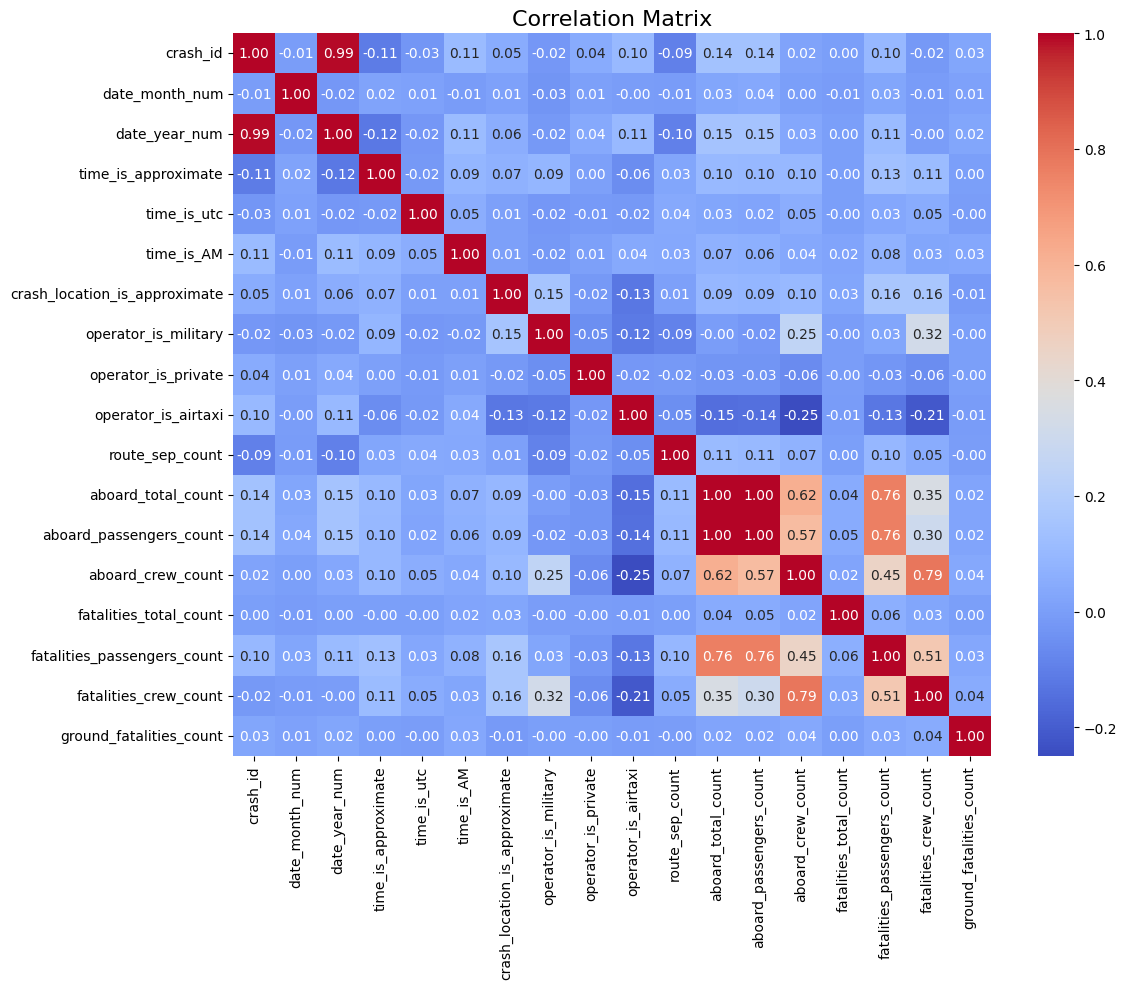

In [98]:
plt.figure(figsize=(12, 10)) 
sns.heatmap(df[num_cols].corr(), 
            annot=True, 
            cmap='coolwarm',
            annot_kws={'size': 10}, 
            fmt='.2f',
            xticklabels=True,
            yticklabels=True)
plt.title('Correlation Matrix', fontsize=16)  
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10) 
plt.tight_layout()  
plt.show()

<code style="color:orange">Notes</code>:

- Ignore `crash_id` on the Correlation Matrix
- The ones that are correlated are the expected ones the derived aboard and fatalities metrics (might need adjustment for modeling)


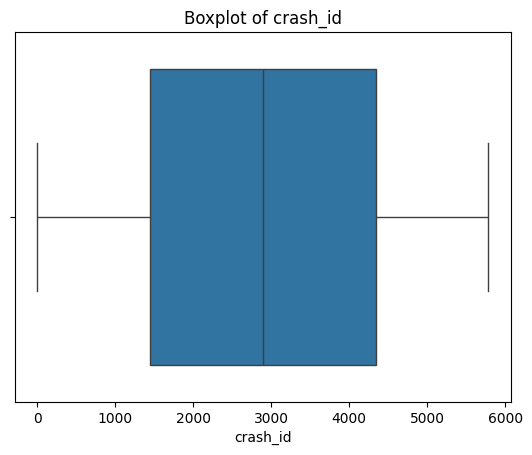

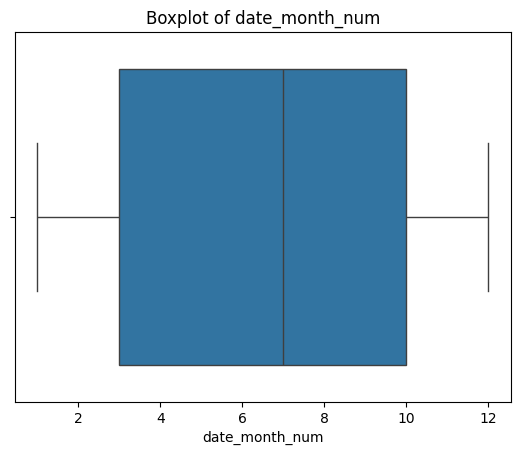

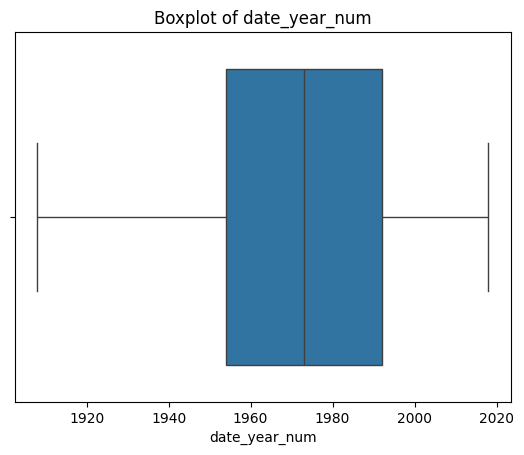

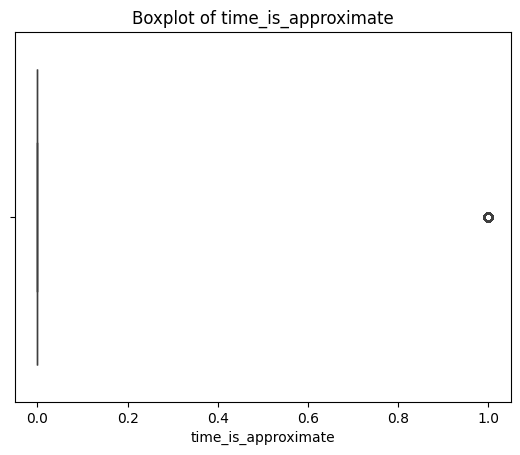

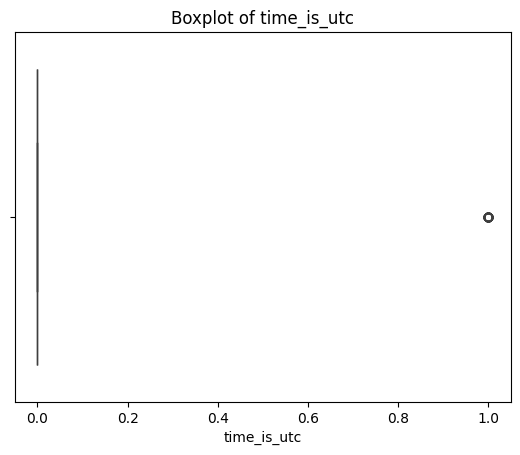

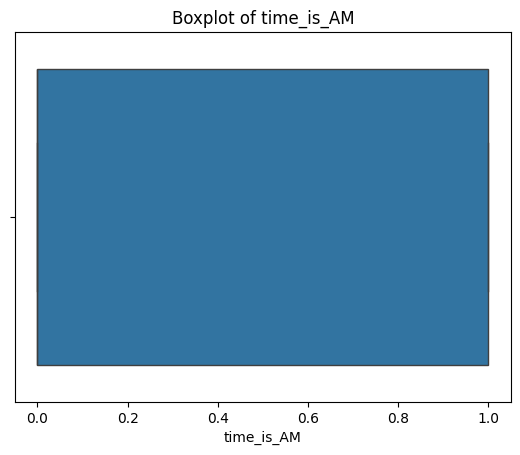

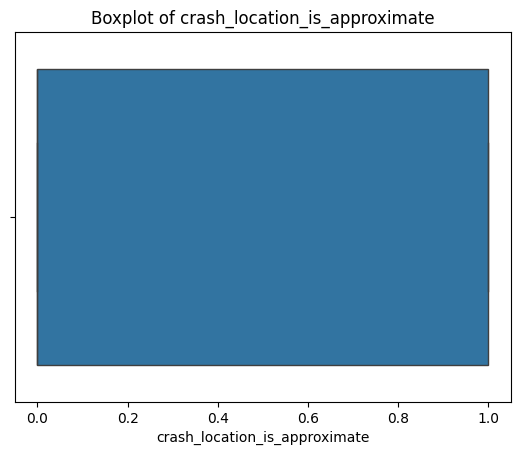

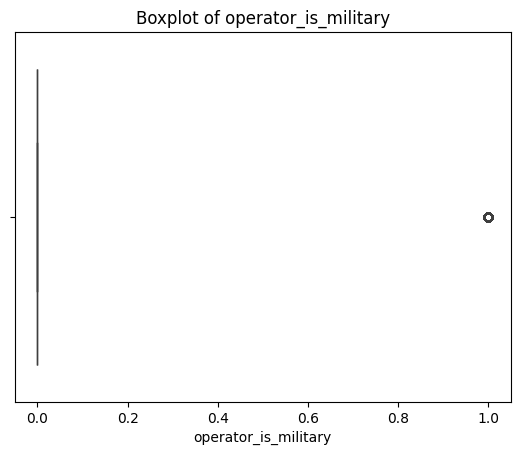

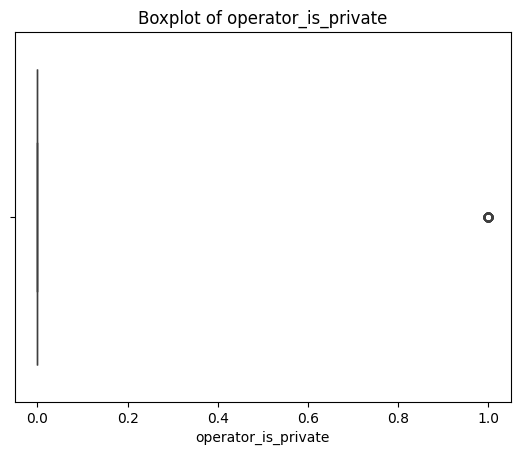

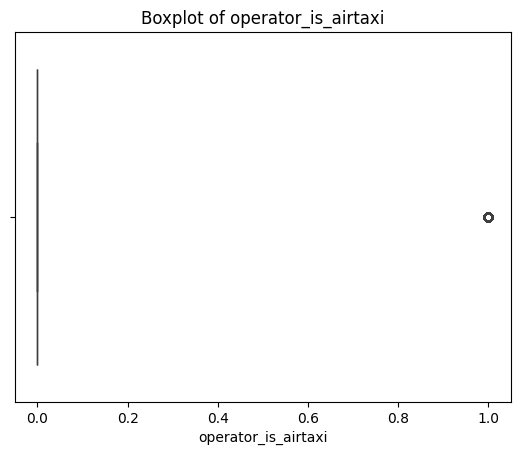

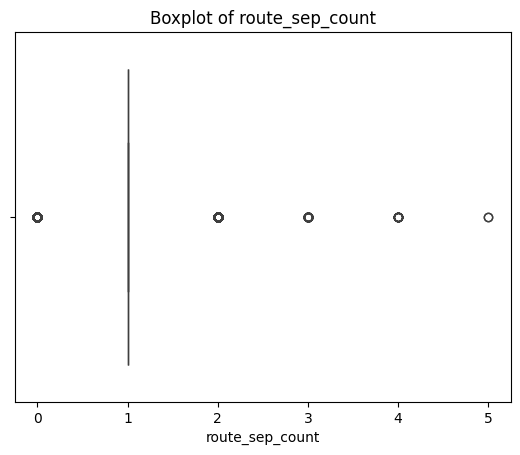

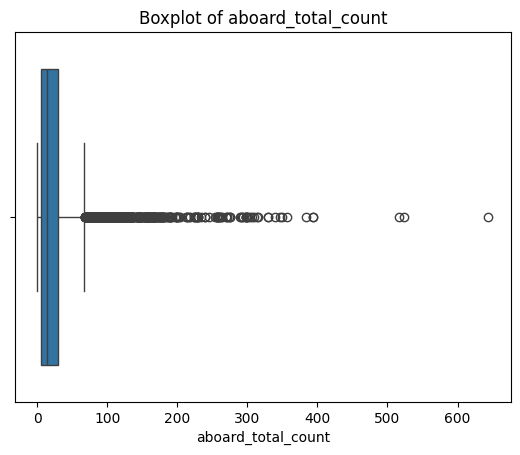

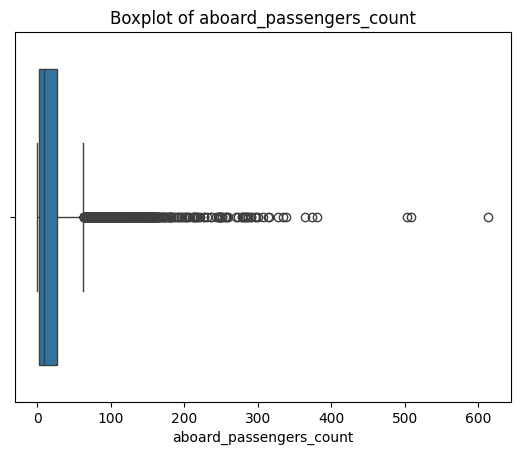

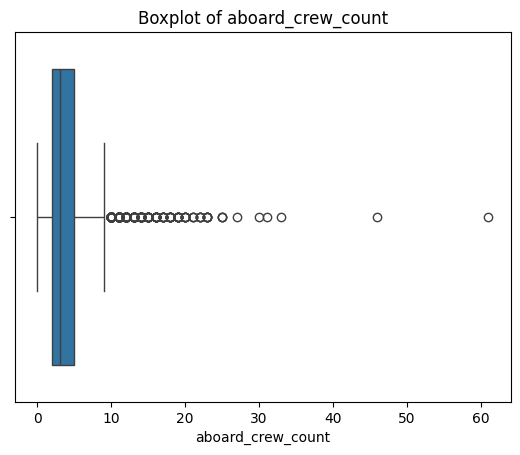

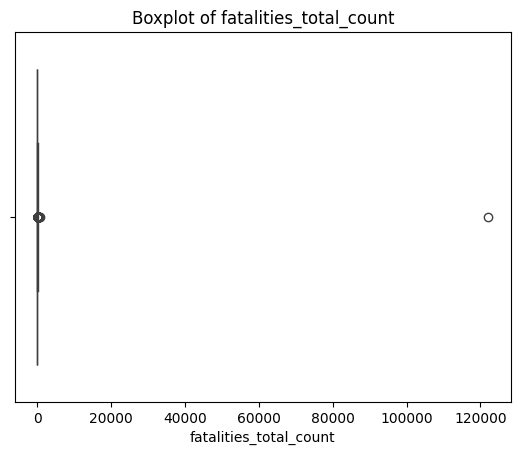

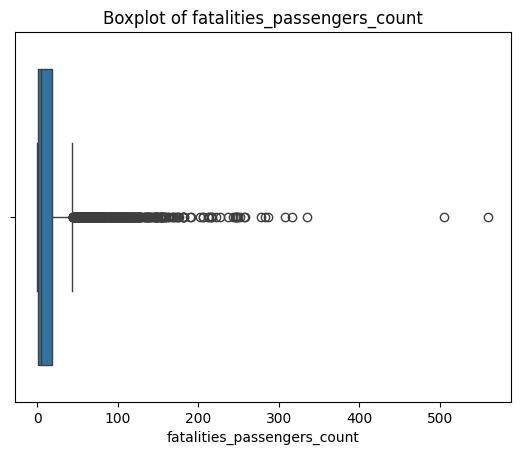

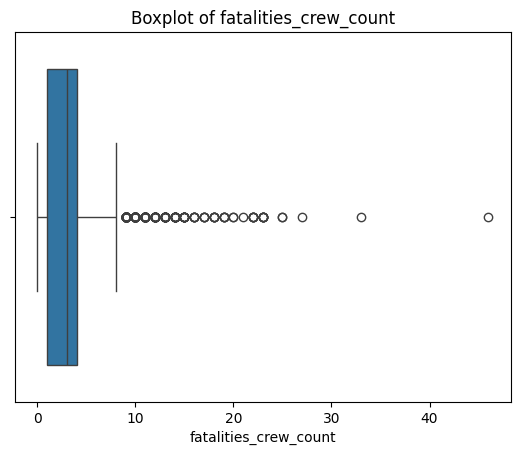

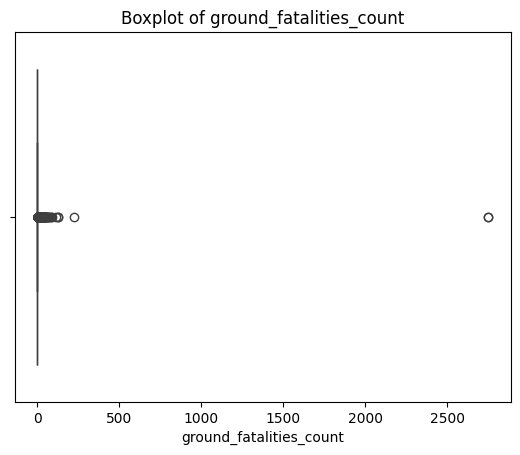

In [99]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## High Cardinality Check (Categorical)

In [100]:
for i, col in enumerate(cat_cols, 1):  
    unique_vals = df[col].nunique()
    if unique_vals > 20:
        print(f"{i}. {col} has high cardinality: {unique_vals} unique values 🔴")
    else:
        print(f"{i}. {col} no high cardinality: {unique_vals} unique values 🟢")

1. date_crash has high cardinality: 5213 unique values 🔴
2. time_crash has high cardinality: 1063 unique values 🔴
3. time_of_day_type no high cardinality: 4 unique values 🟢
4. crash_location_environment_type no high cardinality: 2 unique values 🟢
5. crash_location_text has high cardinality: 4712 unique values 🔴
6. operator_text has high cardinality: 2818 unique values 🔴
7. flight_no_text has high cardinality: 875 unique values 🔴
8. route_text has high cardinality: 3866 unique values 🔴
9. route_from_text has high cardinality: 2211 unique values 🔴
10. route_to_multiple_text has high cardinality: 2616 unique values 🔴
11. ac_type_text has high cardinality: 2668 unique values 🔴
12. ac_type_make_text has high cardinality: 2590 unique values 🔴
13. ac_type_model_text has high cardinality: 2623 unique values 🔴
14. registration_text has high cardinality: 5389 unique values 🔴
15. registration_part1_text has high cardinality: 5387 unique values 🔴
16. registration_part2_text has high cardinality: 1

<code style="color:orange">Notes</code>:

The columns we didcategorize are ok, all others are still free-text based, so high cardinality all over.

In [101]:
# Numeric columns
num_cols = df.select_dtypes(include=['number']).columns

# Total number of rows
total_rows = len(df)

# Profiling stats
profile = df[num_cols].agg(['count', 'min', 'max', 'median', 'mean', 'std']).T

# Add missing count and percent
profile['missing'] = df[num_cols].isnull().sum()
profile['missing_%'] = (profile['missing'] / total_rows * 100).round(2)

# Add non-missing percent for clarity
profile['non_missing_%'] = (profile['count'] / total_rows * 100).round(2)

# Reorder columns for clarity
profile = profile[['count', 'non_missing_%', 'min', 'max', 'median', 'mean', 'std', 'missing', 'missing_%']]

display(profile.round(2))

,count,non_missing_%,min,max,median,mean,std,missing,missing_%
crash_id,5779.0,100.00,1.0,5783.0,2893.0,2892.21,1669.62,0,0.00
date_month_num,5779.0,100.00,1.0,12.0,7.0,6.68,3.54,0,0.00
date_year_num,5779.0,100.00,1908.0,2018.0,1973.0,1972.83,23.69,0,0.00
time_is_approximate,5779.0,100.00,0.0,1.0,0.0,0.06,0.24,0,0.00
time_is_utc,5779.0,100.00,0.0,1.0,0.0,0.01,0.09,0,0.00
time_is_AM,5779.0,100.00,0.0,1.0,0.0,0.27,0.44,0,0.00
crash_location_is_approximate,5779.0,100.00,0.0,1.0,0.0,0.26,0.44,0,0.00
operator_is_military,5779.0,100.00,0.0,1.0,0.0,0.14,0.35,0,0.00
operator_is_private,5779.0,100.00,0.0,1.0,0.0,0.01,0.12,0,0.00
operator_is_airtaxi,5779.0,100.00,0.0,1.0,0.0,0.08,0.26,0,0.00
